# Keyword vs. Semantic Search: A Controlled Validation Study

**Companion notebook to:** *Development of an Intelligent Conversational Assistant for Semantic Exploration of Scientific Articles* — H. El AZZOUZI, K. ETTALBI, O. ROCHDI (Master 2IAD, Chouaïb Doukkali University, 2024–2025).

**Repository:** [scopus_chatbot](https://github.com/ElazzouziHassan/scopus_chatbot)

---

## Purpose

The main paper reports strong retrieval results for a semantic search pipeline (Sentence-Transformers `all-MiniLM-L6-v2` + FAISS) over a 30,063-document arXiv corpus, but it doesn't include a controlled comparison against a keyword-search baseline. This notebook runs that comparison directly: same queries, same conditions, BM25 versus the semantic pipeline, on an independently collected sample, with statistical testing instead of a single point estimate.

## What this notebook does

1. Pulls a fresh, balanced sample of ~1,400 arXiv papers across 7 disciplinary categories.
2. Defines 28 test queries (4 per category), each with a known expected category.
3. Runs BM25 and semantic search (same model as the main system) on every query.
4. Scores both with Precision@5, Precision@10, and Mean Reciprocal Rank, using category match as a relevance proxy.
5. Tests whether the semantic-search advantage is statistically significant (paired Wilcoxon signed-rank test plus bootstrap confidence intervals), not just numerically larger.
6. Breaks results down per category and produces two summary plots.
7. Saves every result table and plot to disk for reuse in the paper or the repo's README.

**How to run:** `Runtime → Run all`. Takes roughly 5–10 minutes on a standard Colab CPU runtime (no GPU required).

**License:** shared under the same license as the parent repository.

In [1]:
# 1. Install dependencies
!pip install -q sentence-transformers rank_bm25 requests pandas numpy scikit-learn scipy matplotlib

In [2]:
import time
import re
import sys
import platform
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

# ---- Configuration (edit here if you want to rerun with different settings) ----
CONFIG = {
    'random_seed': 42,
    'docs_per_category': 200,
    'top_k_precision': [5, 10],
    'mrr_cutoff': 10,
    'model_name': 'all-MiniLM-L6-v2',
    'n_bootstrap': 10000,
}

np.random.seed(CONFIG['random_seed'])

print(f"Run timestamp (UTC): {datetime.now(timezone.utc).isoformat()}")
print(f"Python: {sys.version.split()[0]}  |  Platform: {platform.platform()}")
print(f"Config: {json.dumps(CONFIG, indent=2)}")

NAMESPACES = {
    'atom': 'http://www.w3.org/2005/Atom',
    'arxiv': 'http://arxiv.org/schemas/atom'
}

def get_text(entry, path, default=''):
    el = entry.find(path, NAMESPACES)
    return el.text.strip() if el is not None and el.text else default

Run timestamp (UTC): 2026-08-17T13:21:40.364384+00:00
Python: 3.12.13  |  Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Config: {
  "random_seed": 42,
  "docs_per_category": 200,
  "top_k_precision": [
    5,
    10
  ],
  "mrr_cutoff": 10,
  "model_name": "all-MiniLM-L6-v2",
  "n_bootstrap": 10000
}


## 2. Data acquisition

Same public arXiv API and rate-limiting discipline (1 request/sec, well under arXiv's 3 req/s guidance) as `data/scripts/arxiv_extractor.py` in the main repo. Seven categories span physics, four CS subfields, math, and biology, chosen for topical distinctness so the category-match relevance proxy holds up (a query shouldn't plausibly belong to two categories at once).

In [3]:
BASE_URL = "http://export.arxiv.org/api/query"

CATEGORIES = {
    'quant-ph': 'Quantum Physics',
    'cs.CV':    'Computer Vision',
    'cs.CL':    'Computational Linguistics / NLP',
    'cs.LG':    'Machine Learning',
    'cs.NI':    'Networking and Internet Architecture',
    'math.CO':  'Combinatorics',
    'q-bio.GN': 'Genomics',
}

def fetch_category(category_code, max_results):
    params = {'search_query': f'cat:{category_code}', 'start': 0, 'max_results': max_results,
              'sortBy': 'submittedDate', 'sortOrder': 'descending'}
    resp = requests.get(BASE_URL, params=params, timeout=30)
    resp.raise_for_status()
    root = ET.fromstring(resp.text)
    papers = []
    for entry in root.findall('.//atom:entry', NAMESPACES):
        title = get_text(entry, './atom:title').replace('\n', ' ').strip()
        summary = get_text(entry, './atom:summary').replace('\n', ' ').strip()
        primary_cat_el = entry.find('./arxiv:primary_category', NAMESPACES)
        primary_category = primary_cat_el.get('term') if primary_cat_el is not None else None
        arxiv_id = get_text(entry, './atom:id').split('/')[-1]
        published = get_text(entry, './atom:published')
        papers.append({
            'arxiv_id': arxiv_id,
            'title': title,
            'summary': summary,
            'primary_category': primary_category,
            'published': published,
            'combined_text': f"{title} {summary}".strip()
        })
    return papers

all_papers = []
for code, label in CATEGORIES.items():
    print(f"Fetching {code} ({label})...")
    papers = fetch_category(code, CONFIG['docs_per_category'])
    print(f"  -> {len(papers)} papers retrieved")
    all_papers.extend(papers)
    time.sleep(1)  # respect arXiv rate limits

df = pd.DataFrame(all_papers).drop_duplicates(subset='arxiv_id').reset_index(drop=True)
df = df.dropna(subset=['combined_text', 'primary_category'])
df = df[df['combined_text'].str.len() > 20].reset_index(drop=True)

print(f"\nTotal unique, valid papers collected: {len(df)}")
df['primary_category'].value_counts()

Fetching quant-ph (Quantum Physics)...
  -> 200 papers retrieved
Fetching cs.CV (Computer Vision)...
  -> 200 papers retrieved
Fetching cs.CL (Computational Linguistics / NLP)...
  -> 200 papers retrieved
Fetching cs.LG (Machine Learning)...
  -> 200 papers retrieved
Fetching cs.NI (Networking and Internet Architecture)...
  -> 200 papers retrieved
Fetching math.CO (Combinatorics)...
  -> 200 papers retrieved
Fetching q-bio.GN (Genomics)...
  -> 200 papers retrieved

Total unique, valid papers collected: 1339


,count
primary_category,
cs.LG,183
cs.CV,170
quant-ph,158
math.CO,149
cs.NI,146
...,...
math.AC,1
q-bio.MN,1
cs.PF,1


In [4]:
# Save the raw sample -- useful to include in the GitHub repo for full reproducibility
df.to_csv('sample_corpus.csv', index=False)
print(f"Saved sample_corpus.csv ({len(df)} rows)")

Saved sample_corpus.csv (1339 rows)


## 3. Test queries

28 queries (4 per category), each with a known expected category, written to reflect realistic exploratory research questions, in the same spirit as the examples in the main paper ("quantum machine learning", "reinforcement learning applications").

In [5]:
TEST_QUERIES = [
    ("quantum computing algorithms", "quant-ph"),
    ("quantum machine learning", "quant-ph"),
    ("quantum error correction codes", "quant-ph"),
    ("quantum cryptography protocols", "quant-ph"),

    ("computer vision deep learning", "cs.CV"),
    ("image segmentation neural networks", "cs.CV"),
    ("object detection convolutional networks", "cs.CV"),
    ("video understanding action recognition", "cs.CV"),

    ("natural language processing transformers", "cs.CL"),
    ("large language model reasoning", "cs.CL"),
    ("text summarization neural methods", "cs.CL"),
    ("machine translation sequence models", "cs.CL"),

    ("reinforcement learning applications", "cs.LG"),
    ("few-shot learning generalization", "cs.LG"),
    ("graph neural network representation", "cs.LG"),
    ("self-supervised learning methods", "cs.LG"),

    ("wireless network protocols", "cs.NI"),
    ("network security routing", "cs.NI"),
    ("software defined networking", "cs.NI"),
    ("internet of things communication", "cs.NI"),

    ("graph coloring combinatorics", "math.CO"),
    ("extremal combinatorics results", "math.CO"),
    ("combinatorial optimization algorithms", "math.CO"),
    ("enumerative generating functions", "math.CO"),

    ("genomics sequencing analysis", "q-bio.GN"),
    ("gene expression data analysis", "q-bio.GN"),
    ("genome assembly algorithms", "q-bio.GN"),
    ("single cell RNA sequencing", "q-bio.GN"),
]

print(f"{len(TEST_QUERIES)} test queries across {len(CATEGORIES)} categories "
      f"({len(TEST_QUERIES)//len(CATEGORIES)} per category).")

28 test queries across 7 categories (4 per category).


## 4. Retrieval methods

### 4.1 Keyword baseline: BM25

In [6]:
def simple_tokenize(text):
    return re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())

corpus_tokens = [simple_tokenize(t) for t in df['combined_text'].tolist()]
bm25 = BM25Okapi(corpus_tokens)

def bm25_search(query, k=10):
    scores = bm25.get_scores(simple_tokenize(query))
    top_idx = np.argsort(scores)[::-1][:k]
    return df.iloc[top_idx].reset_index(drop=True)

bm25_search("quantum computing algorithms", k=5)[['title', 'primary_category']]

,title,primary_category
0,AutoQuREO: A Framework for Automated Quantum R...,quant-ph
1,Time evolution of nonlinear dynamics on a quan...,quant-ph
2,Quantum simulation of non-Markovian dynamical ...,quant-ph
3,Evaluating QAOA expectation values can be as h...,quant-ph
4,A Taxonomy of Performance Metrics for the Dist...,cs.DC


### 4.2 Semantic search: Sentence-Transformers + cosine similarity

Same model as the main paper (`all-MiniLM-L6-v2`), same approach of L2-normalizing then taking the inner product, as used with FAISS in the original pipeline. At ~1,400 documents, brute-force cosine similarity is exact and numerically equivalent to FAISS `IndexFlatIP`, so skipping FAISS at this scale introduces no approximation error.

In [7]:
model = SentenceTransformer(CONFIG['model_name'])

print("Embedding corpus...")
doc_embeddings = model.encode(df['combined_text'].tolist(), convert_to_numpy=True,
                               show_progress_bar=True, batch_size=32)

norms = np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
doc_embeddings_norm = doc_embeddings / norms

def semantic_search(query, k=10):
    q_emb = model.encode([query], convert_to_numpy=True)
    q_emb_norm = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    sims = cosine_similarity(q_emb_norm, doc_embeddings_norm)[0]
    top_idx = np.argsort(sims)[::-1][:k]
    return df.iloc[top_idx].reset_index(drop=True)

semantic_search("quantum computing algorithms", k=5)[['title', 'primary_category']]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding corpus...


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

,title,primary_category
0,Clifford Circuit Synthesis for Distributed Qua...,quant-ph
1,Numerical methods for the simulation of quantu...,math.NA
2,Witnessing the architecture of quantum circuits,quant-ph
3,A 12-CNOT Double Qubit Excitation Gate,quant-ph
4,Parity Mapping for Quantum Optimization on Fru...,quant-ph


## 5. Evaluation metrics

Three standard IR metrics, all using the category-match relevance proxy defined above:

- **Precision@5 / Precision@10** — fraction of the top-k results that are relevant.
- **Mean Reciprocal Rank (MRR)** — 1 / (rank of the first relevant result), 0 if none in the top `mrr_cutoff`. Rewards putting a relevant result *early*, which matters for a conversational interface where the top 1–2 results anchor the synthesized answer.

In [8]:
def precision_at_k(results_df, expected_category, k):
    top_k = results_df.head(k)
    relevant = (top_k['primary_category'] == expected_category).sum()
    return relevant / k

def reciprocal_rank(results_df, expected_category, cutoff):
    top = results_df.head(cutoff)
    matches = np.where(top['primary_category'].values == expected_category)[0]
    if len(matches) == 0:
        return 0.0
    return 1.0 / (matches[0] + 1)

max_k = max(CONFIG['top_k_precision'] + [CONFIG['mrr_cutoff']])
rows = []

for query, expected_cat in TEST_QUERIES:
    bm25_results = bm25_search(query, k=max_k)
    semantic_results = semantic_search(query, k=max_k)

    row = {'query': query, 'expected_category': expected_cat}
    for k in CONFIG['top_k_precision']:
        row[f'bm25_p{k}'] = precision_at_k(bm25_results, expected_cat, k)
        row[f'semantic_p{k}'] = precision_at_k(semantic_results, expected_cat, k)
    row['bm25_mrr'] = reciprocal_rank(bm25_results, expected_cat, CONFIG['mrr_cutoff'])
    row['semantic_mrr'] = reciprocal_rank(semantic_results, expected_cat, CONFIG['mrr_cutoff'])
    rows.append(row)

results_table = pd.DataFrame(rows)
results_table.to_csv('per_query_results.csv', index=False)
results_table

,query,expected_category,bm25_p5,semantic_p5,bm25_p10,semantic_p10,bm25_mrr,semantic_mrr
0,quantum computing algorithms,quant-ph,0.8,0.8,0.7,0.9,1.000000,1.000000
1,quantum machine learning,quant-ph,0.4,0.8,0.4,0.9,1.000000,1.000000
2,quantum error correction codes,quant-ph,0.6,0.8,0.8,0.8,1.000000,1.000000
3,quantum cryptography protocols,quant-ph,0.6,0.8,0.7,0.9,1.000000,1.000000
4,computer vision deep learning,cs.CV,0.6,0.8,0.4,0.9,0.500000,1.000000
5,image segmentation neural networks,cs.CV,0.6,0.8,0.7,0.9,0.500000,1.000000
6,object detection convolutional networks,cs.CV,0.6,1.0,0.6,1.0,1.000000,1.000000
7,video understanding action recognition,cs.CV,0.8,0.8,0.8,0.8,1.000000,1.000000
8,natural language processing transformers,cs.CL,0.4,0.8,0.3,0.5,1.000000,1.000000
9,large language model reasoning,cs.CL,0.2,0.6,0.4,0.6,1.000000,1.000000


## 6. Summary statistics

In [9]:
metrics = [f'p{k}' for k in CONFIG['top_k_precision']] + ['mrr']
metric_labels = {f'p{k}': f'Precision@{k}' for k in CONFIG['top_k_precision']}
metric_labels['mrr'] = f"MRR@{CONFIG['mrr_cutoff']}"

summary_rows = []
for m in metrics:
    bm25_vals = results_table[f'bm25_{m}'].values
    sem_vals = results_table[f'semantic_{m}'].values
    summary_rows.append({
        'Metric': metric_labels[m],
        'BM25 mean': bm25_vals.mean(), 'BM25 std': bm25_vals.std(ddof=1),
        'Semantic mean': sem_vals.mean(), 'Semantic std': sem_vals.std(ddof=1),
        'Relative improvement': (sem_vals.mean() - bm25_vals.mean()) / bm25_vals.mean() * 100 if bm25_vals.mean() > 0 else float('nan'),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv('summary_results.csv', index=False)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
summary

,Metric,BM25 mean,BM25 std,Semantic mean,Semantic std,Relative improvement
0,Precision@5,0.5429,0.2821,0.7143,0.2399,31.5789
1,Precision@10,0.5429,0.2530,0.7214,0.2132,32.8947
2,MRR@10,0.8274,0.2957,0.8474,0.2782,2.4152


## 7. Is the difference statistically significant?

A larger mean isn't proof of a real effect with only a couple dozen paired samples, so two checks:

1. **Paired Wilcoxon signed-rank test**, the standard non-parametric test for paired, non-normally-distributed scores like these (Precision@k only takes a handful of discrete values). It tests whether semantic search's per-query scores are systematically higher than BM25's, not just higher on average by chance.
2. **Bootstrap 95% confidence interval** on the mean difference (semantic − BM25), resampling queries with replacement 10,000 times. If the interval excludes 0, the improvement is unlikely to be noise.

In [10]:
def bootstrap_ci_mean_diff(a, b, n_boot=10000, ci=95, seed=CONFIG['random_seed']):
    rng = np.random.default_rng(seed)
    diffs = a - b
    n = len(diffs)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(diffs, size=n, replace=True)
        boot_means[i] = sample.mean()
    lo, hi = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return diffs.mean(), lo, hi

sig_rows = []
for m in metrics:
    bm25_vals = results_table[f'bm25_{m}'].values
    sem_vals = results_table[f'semantic_{m}'].values

    diffs = sem_vals - bm25_vals
    if np.allclose(diffs, 0):
        wilcoxon_stat, wilcoxon_p = float('nan'), 1.0
    else:
        wilcoxon_stat, wilcoxon_p = stats.wilcoxon(sem_vals, bm25_vals, zero_method='wilcox')

    mean_diff, ci_lo, ci_hi = bootstrap_ci_mean_diff(sem_vals, bm25_vals, n_boot=CONFIG['n_bootstrap'])

    sig_rows.append({
        'Metric': metric_labels[m],
        'Mean diff (semantic - BM25)': mean_diff,
        '95% CI low': ci_lo,
        '95% CI high': ci_hi,
        'Wilcoxon p-value': wilcoxon_p,
        'Significant (p<0.05)': wilcoxon_p < 0.05,
    })

significance_table = pd.DataFrame(sig_rows)
significance_table.to_csv('significance_results.csv', index=False)
significance_table

,Metric,Mean diff (semantic - BM25),95% CI low,95% CI high,Wilcoxon p-value,Significant (p<0.05)
0,Precision@5,0.1714,0.0786,0.2571,0.0047,True
1,Precision@10,0.1786,0.1000,0.2607,0.0004,True
2,MRR@10,0.0200,-0.0774,0.1173,0.7598,False


## 8. Per-category breakdown

Worth looking at on its own: the main paper's Limitations section notes that documents spanning multiple domains tend to get overgeneralized. A per-category breakdown can show whether semantic search's advantage is uniform or concentrated in a few topic areas.

In [11]:
category_summary = results_table.groupby('expected_category').agg(
    bm25_p5_mean=('bm25_p5', 'mean'),
    semantic_p5_mean=('semantic_p5', 'mean'),
    n_queries=('query', 'count')
).reset_index()
category_summary['category_label'] = category_summary['expected_category'].map(CATEGORIES)
category_summary = category_summary[['expected_category', 'category_label', 'n_queries', 'bm25_p5_mean', 'semantic_p5_mean']]
category_summary.to_csv('per_category_results.csv', index=False)
category_summary

,expected_category,category_label,n_queries,bm25_p5_mean,semantic_p5_mean
0,cs.CL,Computational Linguistics / NLP,4,0.4000,0.8000
1,cs.CV,Computer Vision,4,0.6500,0.8500
2,cs.LG,Machine Learning,4,0.2500,0.3000
3,cs.NI,Networking and Internet Architecture,4,0.5000,0.7500
4,math.CO,Combinatorics,4,0.6500,0.8000
5,q-bio.GN,Genomics,4,0.7500,0.7000
6,quant-ph,Quantum Physics,4,0.6000,0.8000


## 9. Plots

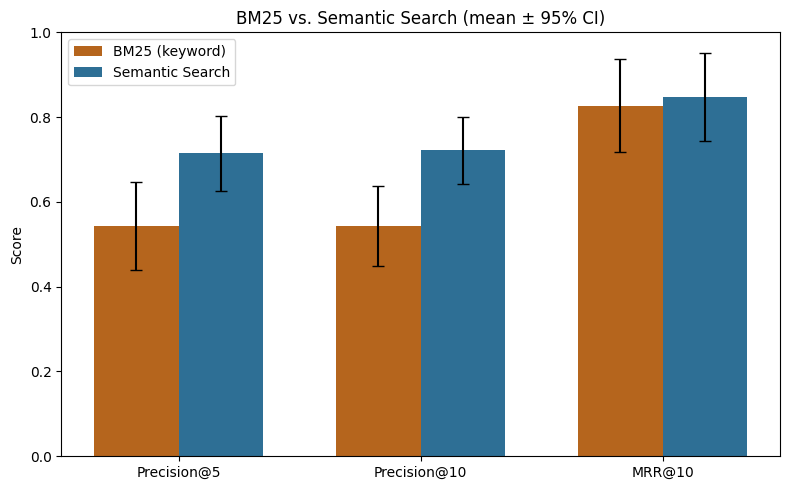

In [12]:
# Plot 1: grouped bar chart, mean +/- 95% CI per metric
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
width = 0.35

bm25_means = [results_table[f'bm25_{m}'].mean() for m in metrics]
bm25_errs = [1.96 * results_table[f'bm25_{m}'].std(ddof=1) / np.sqrt(len(results_table)) for m in metrics]
sem_means = [results_table[f'semantic_{m}'].mean() for m in metrics]
sem_errs = [1.96 * results_table[f'semantic_{m}'].std(ddof=1) / np.sqrt(len(results_table)) for m in metrics]

ax.bar(x - width/2, bm25_means, width, yerr=bm25_errs, capsize=4, label='BM25 (keyword)', color='#B5651D')
ax.bar(x + width/2, sem_means, width, yerr=sem_errs, capsize=4, label='Semantic Search', color='#2E6F95')
ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metrics])
ax.set_ylabel('Score')
ax.set_title('BM25 vs. Semantic Search (mean ± 95% CI)')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('comparison_barchart.png', dpi=150)
plt.show()

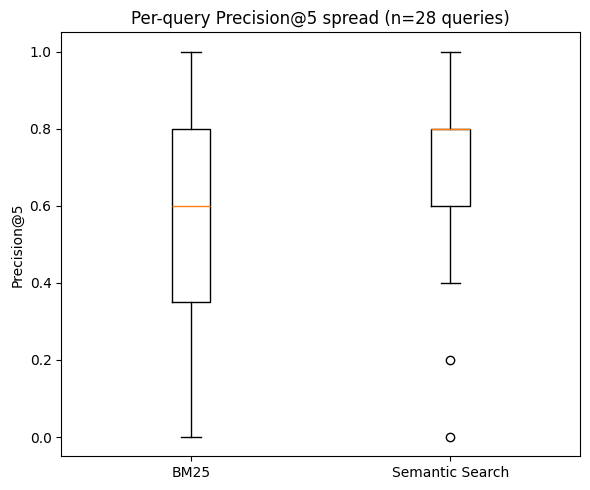

In [13]:
# Plot 2: per-query Precision@5 distribution (boxplot)
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([results_table['bm25_p5'], results_table['semantic_p5']],
           tick_labels=['BM25', 'Semantic Search'])
ax.set_ylabel('Precision@5')
ax.set_title('Per-query Precision@5 spread (n=%d queries)' % len(results_table))
plt.tight_layout()
plt.savefig('comparison_boxplot.png', dpi=150)
plt.show()